# Dataset Overview
Basic stats on the PTC corpus.

In [1]:
import sys
sys.path.append('..')

from src.data.corpus import load_corpus
from src.data.splits import make_splits
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plt.rcParams['figure.dpi'] = 120

In [2]:
train_all = load_corpus('train', '../data')
dev_unlabelled = load_corpus('dev', '../data')
train, dev, test = make_splits(train_all, seed=42)

print('=== Corpus size ===')
print(f'All labelled articles:    {len(train_all)}')
print(f'Unlabelled dev articles:  {len(dev_unlabelled)}')
print()
print('=== Our splits ===')
print(f'Train: {len(train)}')
print(f'Dev:   {len(dev)}')
print(f'Test:  {len(test)}')

=== Corpus size ===
All labelled articles:    371
Unlabelled dev articles:  75

=== Our splits ===
Train: 289
Dev:   41
Test:  41


In [3]:
# Span counts per split (fixed due to seed=42 — safe to quote in dissertation)
def split_stats(name, split):
    n_articles = len(split)
    n_si_spans = sum(len(a.si_spans) for a in split)
    n_tc_spans = sum(len(a.tc_spans) for a in split)
    print(f'{name:<8}  articles: {n_articles:>4}  SI spans: {n_si_spans:>5}  TC spans: {n_tc_spans:>5}')

print('=== Span counts per split (seed=42, deterministic) ===')
split_stats('Train', train)
split_stats('Dev',   dev)
split_stats('Test',  test)
split_stats('TOTAL', train + dev + test)

=== Span counts per split (seed=42, deterministic) ===
Train     articles:  289  SI spans:  4396  TC spans:  4897
Dev       articles:   41  SI spans:   607  TC spans:   662
Test      articles:   41  SI spans:   465  TC spans:   570
TOTAL     articles:  371  SI spans:  5468  TC spans:  6129


In [4]:
# Article length distribution
lengths = [len(a.text) for a in train_all]

print('=== Article length (characters) ===')
print(f'Min:    {min(lengths)}')
print(f'Max:    {max(lengths)}')
print(f'Mean:   {np.mean(lengths):.0f}')
print(f'Median: {np.median(lengths):.0f}')

=== Article length (characters) ===
Min:    761
Max:    47473
Mean:   5612
Median: 4184


In [5]:
# Propaganda span counts
si_counts = [len(a.si_spans) for a in train_all]
articles_with_spans = sum(1 for c in si_counts if c > 0)

print('=== Propaganda spans per article (SI) ===')
print(f'Articles with no spans:   {sum(1 for c in si_counts if c == 0)}')
print(f'Articles with spans:      {articles_with_spans}')
print(f'Mean spans per article:   {np.mean(si_counts):.1f}')
print(f'Max spans in one article: {max(si_counts)}')

=== Propaganda spans per article (SI) ===
Articles with no spans:   14
Articles with spans:      357
Mean spans per article:   14.7
Max spans in one article: 192


In [6]:
# Technique distribution
technique_counts = Counter()
for a in train_all:
    for span in a.tc_spans:
        technique_counts[span.technique] += 1

total = sum(technique_counts.values())
print('=== Technique distribution (TC) ===')
print('%-45s %6s  %8s' % ('Technique', 'Count', '% total'))
print('-' * 65)
for technique, count in technique_counts.most_common():
    print('%-45s %6d  %7.1f%%' % (technique, count, count/total*100))
print('%-45s %6d' % ('TOTAL', total))

=== Technique distribution (TC) ===
Technique                                      Count   % total
-----------------------------------------------------------------
Loaded_Language                                 2123     34.6%
Name_Calling,Labeling                           1058     17.3%
Repetition                                       621     10.1%
Doubt                                            493      8.0%
Exaggeration,Minimisation                        466      7.6%
Appeal_to_fear-prejudice                         294      4.8%
Flag-Waving                                      229      3.7%
Causal_Oversimplification                        209      3.4%
Appeal_to_Authority                              144      2.3%
Slogans                                          129      2.1%
Whataboutism,Straw_Men,Red_Herring               108      1.8%
Black-and-White_Fallacy                          107      1.7%
Thought-terminating_Cliches                       76      1.2%
Bandwagon,Reduct

## Training Set Analysis
Stats below use only the **train split** (289 articles, seed=42).

In [7]:
# Span length stats — training set
span_lengths = [span.end - span.start for a in train for span in a.si_spans]

shortest_idx = int(np.argmin(span_lengths))
longest_idx  = int(np.argmax(span_lengths))

# Find the actual spans for display
all_spans_with_text = [
    (span.end - span.start, a.text[span.start:span.end])
    for a in train for span in a.si_spans
]
all_spans_with_text.sort(key=lambda x: x[0])

print('=== Span length (characters) — train split ===')
print(f'Total spans: {len(span_lengths)}')
print(f'Min:         {min(span_lengths)}')
print(f'Max:         {max(span_lengths)}')
print(f'Mean:        {np.mean(span_lengths):.1f}')
print(f'Median:      {np.median(span_lengths):.1f}')
print(f'Std:         {np.std(span_lengths):.1f}')
print()
print(f'Shortest span ({all_spans_with_text[0][0]} chars):')
print(f'  "{all_spans_with_text[0][1]}"')
print()
print(f'Longest span ({all_spans_with_text[-1][0]} chars):')
print(f'  "{all_spans_with_text[-1][1][:120]}..."')

=== Span length (characters) — train split ===
Total spans: 4396
Min:         2
Max:         712
Mean:        48.5
Median:      25.0
Std:         61.4

Shortest span (2 chars):
  "NO"

Longest span (712 chars):
  "Fatimid caliph Al-Amir bi-Ahkamillah issued this edict:
Now, the prior degradation of the infidels in this world before ..."


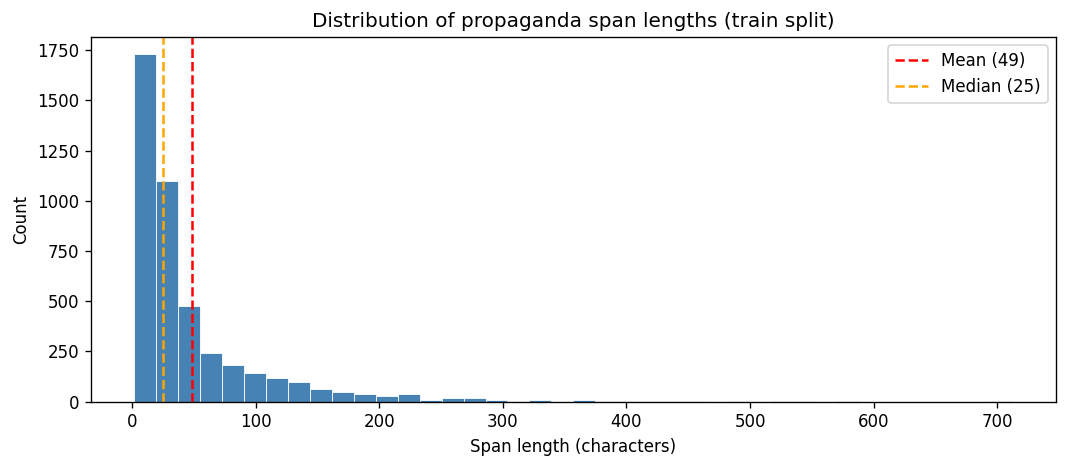

In [8]:
# Histogram of span lengths — training set
fig, ax = plt.subplots(figsize=(9, 4))

ax.hist(span_lengths, bins=40, color='steelblue', edgecolor='white', linewidth=0.5)
ax.axvline(np.mean(span_lengths),   color='red',    linestyle='--', linewidth=1.5, label=f'Mean ({np.mean(span_lengths):.0f})')
ax.axvline(np.median(span_lengths), color='orange', linestyle='--', linewidth=1.5, label=f'Median ({np.median(span_lengths):.0f})')

ax.set_xlabel('Span length (characters)')
ax.set_ylabel('Count')
ax.set_title('Distribution of propaganda span lengths (train split)')
ax.legend()
plt.tight_layout()
plt.show()

=== Character-level class imbalance (train split) ===
Total characters:       1,643,984
Propaganda:             213,397  (13.0%)
Non-propaganda:         1,430,587  (87.0%)
Imbalance ratio:        1 : 6.7


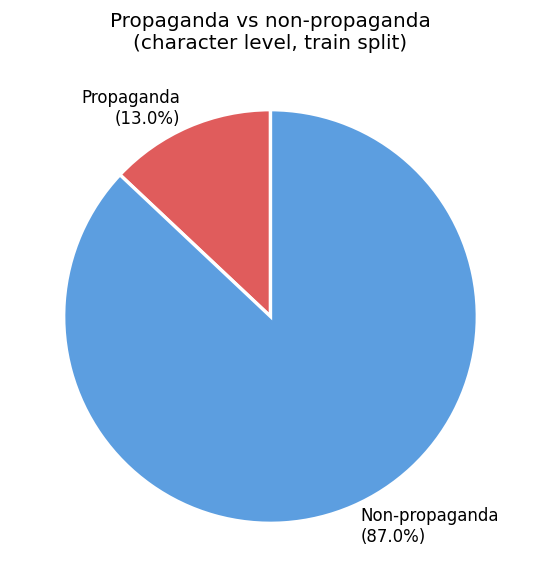

In [9]:
# Propaganda vs non-propaganda class imbalance — training set
total_chars   = sum(len(a.text) for a in train)
prop_chars    = sum(span.end - span.start for a in train for span in a.si_spans)
nonprop_chars = total_chars - prop_chars

print('=== Character-level class imbalance (train split) ===')
print(f'Total characters:       {total_chars:,}')
print(f'Propaganda:             {prop_chars:,}  ({prop_chars/total_chars*100:.1f}%)')
print(f'Non-propaganda:         {nonprop_chars:,}  ({nonprop_chars/total_chars*100:.1f}%)')
print(f'Imbalance ratio:        1 : {nonprop_chars/prop_chars:.1f}')

fig, ax = plt.subplots(figsize=(5, 5))
sizes  = [prop_chars, nonprop_chars]
labels = [f'Propaganda\n({prop_chars/total_chars*100:.1f}%)', f'Non-propaganda\n({nonprop_chars/total_chars*100:.1f}%)']
colors = ['#e05c5c', '#5c9ee0']
ax.pie(sizes, labels=labels, colors=colors, startangle=90,
       wedgeprops=dict(edgecolor='white', linewidth=2))
ax.set_title('Propaganda vs non-propaganda\n(character level, train split)')
plt.tight_layout()
plt.show()

=== Spans per article (train split) ===
Articles with 0 spans:  12
Articles with 1+ spans: 277
Min:    0
Max:    192
Mean:   15.21
Median: 11.0
Std:    17.96


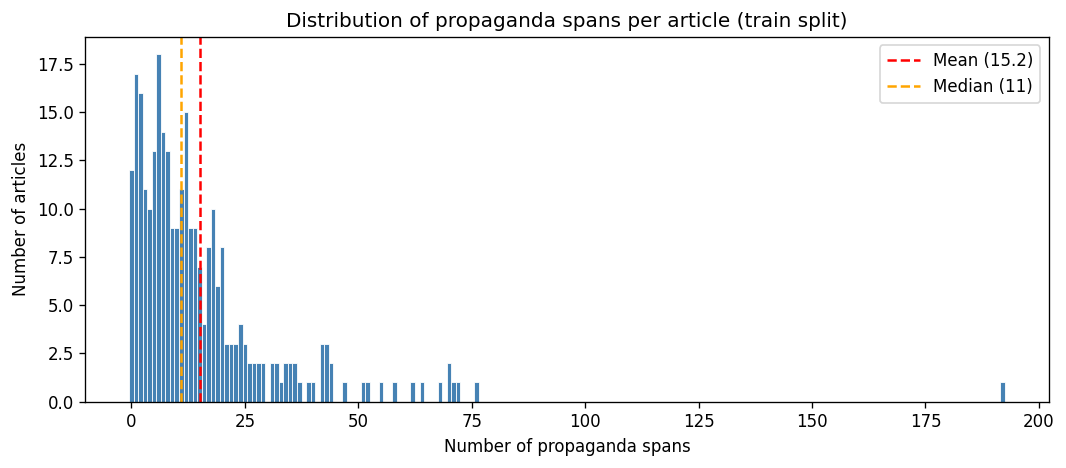

In [10]:
# Distribution of spans per article — training set
spans_per_article = [len(a.si_spans) for a in train]

print('=== Spans per article (train split) ===')
print(f'Articles with 0 spans:  {spans_per_article.count(0)}')
print(f'Articles with 1+ spans: {sum(1 for c in spans_per_article if c > 0)}')
print(f'Min:    {min(spans_per_article)}')
print(f'Max:    {max(spans_per_article)}')
print(f'Mean:   {np.mean(spans_per_article):.2f}')
print(f'Median: {np.median(spans_per_article):.1f}')
print(f'Std:    {np.std(spans_per_article):.2f}')

fig, ax = plt.subplots(figsize=(9, 4))
max_spans = max(spans_per_article)
bins = range(0, max_spans + 2)
ax.hist(spans_per_article, bins=bins, align='left', color='steelblue', edgecolor='white', linewidth=0.5)
ax.axvline(np.mean(spans_per_article),   color='red',    linestyle='--', linewidth=1.5, label=f'Mean ({np.mean(spans_per_article):.1f})')
ax.axvline(np.median(spans_per_article), color='orange', linestyle='--', linewidth=1.5, label=f'Median ({np.median(spans_per_article):.0f})')
ax.set_xlabel('Number of propaganda spans')
ax.set_ylabel('Number of articles')
ax.set_title('Distribution of propaganda spans per article (train split)')
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
ax.legend()
plt.tight_layout()
plt.show()

In [11]:
# Class imbalance for SI: proportion of propaganda tokens
total_chars = sum(len(a.text) for a in train_all)
propaganda_chars = sum(span.end - span.start for a in train_all for span in a.si_spans)

print('=== Token-level imbalance (full labelled corpus) ===')
print(f'Total characters:       {total_chars:,}')
print(f'Propaganda characters:  {propaganda_chars:,}  ({propaganda_chars/total_chars*100:.1f}%)')
print(f'Non-propaganda:         {total_chars-propaganda_chars:,}  ({(total_chars-propaganda_chars)/total_chars*100:.1f}%)')

=== Token-level imbalance (full labelled corpus) ===
Total characters:       2,081,888
Propaganda characters:  275,776  (13.2%)
Non-propaganda:         1,806,112  (86.8%)
